## Lab assignment 02

### Neural Machine Translation in the wild
In the second homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [ ]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

# ! pip  install subword-nmt
# ! pip install nltk
# ! pip install torchtext

In [16]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
import requests

path_do_data = './data.txt'

if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading...")
    url = "https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt"
    r = requests.get(url)
    with open(path_do_data, 'wb') as f:
        f.write(r.content)
    print("Download complete.")
else:
    print("Dataset already exists.")

Dataset already exists.


#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [17]:
!pip install pandas scikit-learn matplotlib ipykernel nltk tqdm

In [18]:
!pip install torch

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from nltk.tokenize import WordPunctTokenizer
import time
import math
from IPython.display import clear_output

### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [20]:
df = pd.read_csv('./data.txt', sep='\t', header=None, names=['trg', 'src'])

train_df, test_df = train_test_split(df, test_size=0.05, random_state=42)
train_df, valid_df = train_test_split(train_df, test_size=0.15/0.95, random_state=42)

df.head(10)

,trg,src
0,"Cordelia Hotel is situated in Tbilisi, a 3-min...","Отель Cordelia расположен в Тбилиси, в 3 минут..."
1,At Tupirmarka Lodge you will find a 24-hour fr...,В числе удобств лоджа Tupirmarka круглосуточна...
2,"Featuring free WiFi in all areas, Naigao Xiaow...",Апартаменты Naigao Xiaowo расположены в городе...
3,Each has a TV and a private bathroom with shower.,В вашем распоряжении также телевизор и собстве...
4,Your room comes with air conditioning and sate...,Номер оснащен кондиционером и спутниковым теле...
5,They are styled in cream-coloured hues and som...,"Они оформлены в кремовых тонах, в некоторых из..."
6,The reception team can help guests plan sights...,Сотрудники стойки регистрации с радостью помог...
7,Some units include a seating area for your con...,В числе удобств некоторых номеров — гостиная з...
8,"Nieuwmarkt as well as Kalverstraat, Hermitage ...","До площади Ниумаркт, торговой улицы Калверштра..."
9,The Danube Delta is a natural reserve where yo...,"Дельта Дуная является природным заповедником, ..."


In [21]:
tokenizer_W = WordPunctTokenizer()
def tokenize(text):
    return tokenizer_W.tokenize(str(text).lower())

def build_vocab(texts, min_freq=3):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    # <unk>=0, <pad>=1, <sos>=2, <eos>=3
    vocab = {'<unk>': 0, '<pad>': 1, '<sos>': 2, '<eos>': 3}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

In [22]:
src_vocab = build_vocab(train_df['src'], min_freq=3)
trg_vocab = build_vocab(train_df['trg'], min_freq=3)

In [23]:
class TranslationDataset(Dataset):
    def __init__(self, df, src_vocab, trg_vocab):
        self.df = df
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_ids = [self.src_vocab.get(token, 0) for token in tokenize(row['src'])]
        trg_ids = [self.trg_vocab.get(token, 0) for token in tokenize(row['trg'])]
        return (torch.tensor([2] + src_ids + [3]), torch.tensor([2] + trg_ids + [3]))

class BatchWrapper:
    def __init__(self, src, trg):
        self.src = src
        self.trg = trg

def collate_fn(batch):
    src_list, trg_list = zip(*batch)
    src_padded = pad_sequence(src_list, padding_value=1, batch_first=False)
    trg_padded = pad_sequence(trg_list, padding_value=1, batch_first=False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return BatchWrapper(src_padded.to(device), trg_padded.to(device))

BATCH_SIZE = 128
train_iterator = DataLoader(TranslationDataset(train_df, src_vocab, trg_vocab), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_iterator = DataLoader(TranslationDataset(valid_df, src_vocab, trg_vocab), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_iterator = DataLoader(TranslationDataset(test_df, src_vocab, trg_vocab), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

мы загрузили и предобработали бейзлайново датасет. теперь построим график распределения длин чтобы понять нормальные ли у нас размеры выборок

Statistics for Train data:


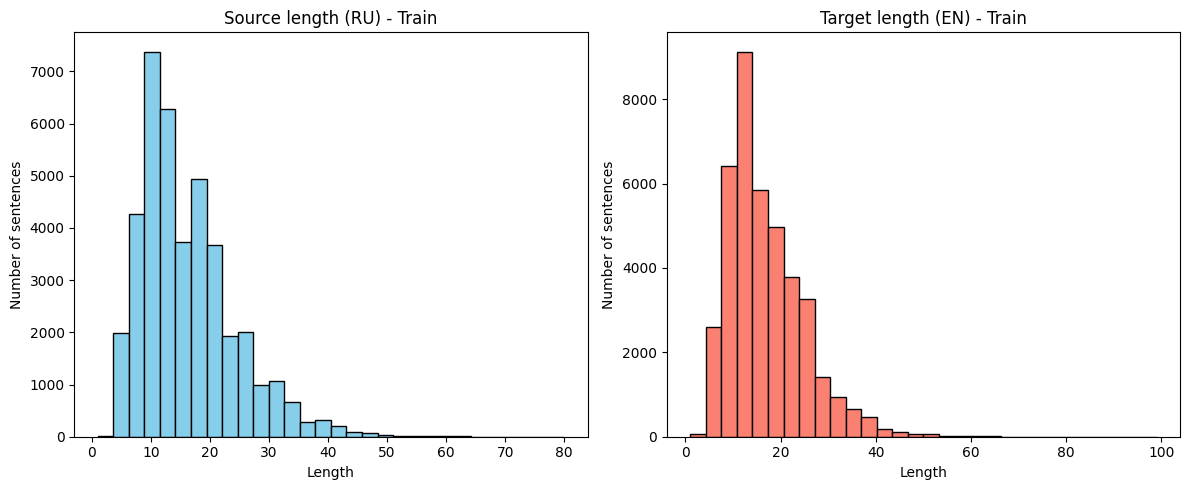

Statistics for Test data:


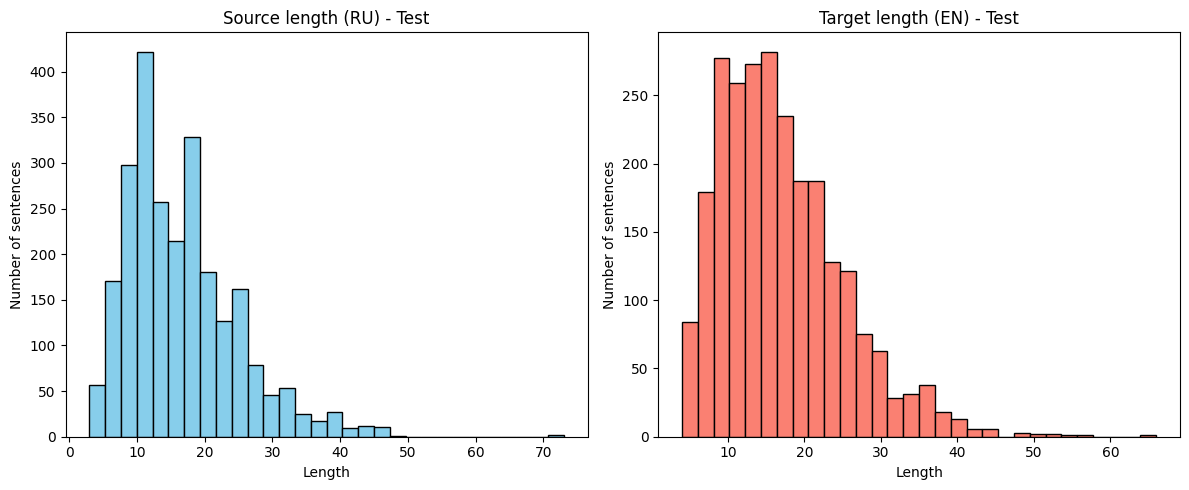

Mean RU length: 16.17
Mean EN length: 16.90


In [24]:
import matplotlib.pyplot as plt

# 1. Вычисляем длины предложений (кол-во токенов)
# Применяем нашу функцию tokenize к каждой строке
train_src_len = train_df['src'].apply(lambda x: len(tokenize(x)))
train_trg_len = train_df['trg'].apply(lambda x: len(tokenize(x)))

test_src_len = test_df['src'].apply(lambda x: len(tokenize(x)))
test_trg_len = test_df['trg'].apply(lambda x: len(tokenize(x)))

# 2. Строим графики для тренировочной выборки
print(f"Statistics for Train data:")
plt.figure(figsize=[12, 5])

plt.subplot(1, 2, 1)
plt.title("Source length (RU) - Train")
plt.hist(train_src_len, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Length')
plt.ylabel('Number of sentences')

plt.subplot(1, 2, 2)
plt.title("Target length (EN) - Train")
plt.hist(train_trg_len, bins=30, color='salmon', edgecolor='black')
plt.xlabel('Length')
plt.ylabel('Number of sentences')

plt.tight_layout()
plt.show()

# 3. Строим графики для тестовой выборки
print(f"Statistics for Test data:")
plt.figure(figsize=[12, 5])

plt.subplot(1, 2, 1)
plt.title("Source length (RU) - Test")
plt.hist(test_src_len, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Length')
plt.ylabel('Number of sentences')

plt.subplot(1, 2, 2)
plt.title("Target length (EN) - Test")
plt.hist(test_trg_len, bins=30, color='salmon', edgecolor='black')
plt.xlabel('Length')
plt.ylabel('Number of sentences')

plt.tight_layout()
plt.show()

# Выведем еще средние значения, чтобы понимать масштаб
print(f"Mean RU length: {train_src_len.mean():.2f}")
print(f"Mean EN length: {train_trg_len.mean():.2f}")

распределения совпадают по форме, поэтому можно приступать к обучению бейзлайна

бейзлайном будет простая модель RNN с простой предобработкой выше. После нее мы будем делать улучшения для того, чтобы улучшить метрику BLEU

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [26]:
device

device(type='cpu')

In [29]:
import my_network_rnn
Encoder = my_network_rnn.Encoder
Decoder = my_network_rnn.Decoder
Seq2Seq = my_network_rnn.Seq2Seq

In [30]:
import torch.optim as optim
import time
import math

INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(trg_vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

In [31]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

PAD_IDX = trg_vocab['<pad>']
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index = PAD_IDX)

In [32]:
print(f'The model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters')

The model has 14,910,806 trainable parameters


In [33]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()
    epoch_loss = 0
    history = []
    
    for i, batch in enumerate(iterator):
        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()
        
        # model(src, trg) выдает [trg_len, batch_size, vocab_size]
        output = model(src, trg)
        
        # Для Loss-функции нам нужно "схлопнуть" размерности:
        # Мы отрезаем <sos> (0-й индекс), так как его не надо предсказывать
        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()

        # Clipping градиентов предотвращает их "взрыв"
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()
        
        # Рисуем графики лосса в реальном времени
        history.append(loss.cpu().data.numpy())
        if (i+1) % 10 == 0:
            clear_output(True)
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
            ax[0].plot(history, label='train loss')
            ax[0].set_title('Current Batch Loss')
            if train_history: ax[1].plot(train_history, label='train history')
            if valid_history: ax[1].plot(valid_history, label='valid history')
            ax[1].set_title('Epoch History')
            plt.legend()
            plt.show()

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src = batch.src
            trg = batch.trg
            
            # teacher_forcing_ratio = 0 (модель переводит сама, без подсказок)
            output = model(src, trg, 0) 

            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()
            
    return epoch_loss / len(iterator)

In [34]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)
    
    end_time = time.time()
    
    epoch_mins = int((end_time - start_time) // 60)
    epoch_secs = int((end_time - start_time) % 60)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best-val-model.pt')
    
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

KeyboardInterrupt: 

__Let's take a look at our network quality__:

In [35]:
from nltk.translate.bleu_score import corpus_bleu

# 1. Загружаем лучшие веса
model.load_state_dict(torch.load('best-val-model.pt'))

# 2. Вспомогательная функция для превращения ID обратно в слова
id_to_word = {v: k for k, v in trg_vocab.items()}

def get_text(tokens, vocab_inv):
    text = []
    for token in tokens:
        word = vocab_inv.get(token, '<unk>')
        if word == '<eos>': break
        if word not in ['<sos>', '<pad>', '<unk>']:
            text.append(word)
    return text

original_text = []
generated_text = []

model.eval()
with torch.no_grad():
    for batch in test_iterator:
        src = batch.src
        trg = batch.trg
        output = model(src, trg, 0) # [len, batch, vocab]
        
        output = output.argmax(2).cpu().numpy() # [len, batch]
        trg = trg.cpu().numpy() # [len, batch]
        
        for i in range(trg.shape[1]):
            original_text.append([get_text(trg[:, i], id_to_word)])
            generated_text.append(get_text(output[1:, i], id_to_word))

# 3. Считаем итоговый BLEU
bleu_score = corpus_bleu(original_text, generated_text) * 100
print(f'Final Baseline BLEU score: {bleu_score:.2f}')

FileNotFoundError: [Errno 2] No such file or directory: 'best-val-model.pt'

In [ ]:
del utils

In [ ]:
import utils
import imp
imp.reload(utils)
generate_translation = utils.generate_translation
remove_tech_tokens = utils.remove_tech_tokens
get_text = utils.get_text
flatten = utils.flatten

In [ ]:
batch = next(iter(test_iterator))

In [ ]:
for idx in [1,2]:
    src = batch.src[:, idx:idx+1]
    trg = batch.trg[:, idx:idx+1]
    generate_translation(src, trg, model, TRG.vocab)

Original: there is a 24 - hour front desk at the property .
Generated: the property offers a 24 - hour front desk . .

Original: this property also features free wifi .
Generated: free wifi access . . . .



In [ ]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [ ]:
import tqdm

In [ ]:
original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_iterator)):

        src = batch.src
        trg = batch.trg

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# original_text = flatten(original_text)
# generated_text = flatten(generated_text)

59it [00:03, 18.87it/s]


In [ ]:
corpus_bleu([[text] for text in original_text], generated_text) * 100

14.139920232081806